# 25. Страхование: частота (Пуассон), ущерб (Твиди), экспозиция — 200 000 полисов

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`25_insurance_poisson_tweedie.py`](../25_insurance_poisson_tweedie.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Моделировать счётные и «нулевые с хвостом» величины правильной функцией потерь.

### Чему вы научитесь

- Экспозиция (доля года под страховкой) через смещение `init_score` = log(экспозиции)
- Потеря Пуассона для числа случаев
- Потеря Твиди для суммарного ущерба — много нулей и тяжёлый хвост
- Девиация как метрика
- Проверка калибровки по группам и по суммам

### Данные

`_data.make_claims` — 200 000 полисов ОСАГО: возраст, стаж, мощность, возраст авто, регион, тип, бонус-малус; число случаев (у ~96% — ноль), ущерб в рублях, экспозиция 0.1–1.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Число случаев: MSE против Пуассона (без экспозиции)
3. **Этап 3.** Экспозиция: полис на 3 месяца видит в 4 раза меньше случаев, чем годовой
4. **Этап 4.** Суммарный ущерб: Твиди (1 < p < 2) — точная масса в нуле плюс непрерывный хвост
5. **Этап 5.** Калибровка по децилям прогноза частоты: ожидаемое против фактического
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/25_insurance_poisson_tweedie.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_claims

ex = Example(EXAMPLES / "4_large/25_insurance_poisson_tweedie.py", title="25. Страхование: Пуассон и Твиди",
             goal="моделировать частоту и ущерб правильными потерями с учётом экспозиции")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.metrics import mean_poisson_deviance, mean_tweedie_deviance

## Этап 1. Данные

In [2]:
X, claims, amount, exposure = make_claims(ex.size(200_000, 50_000))
ex.describe(X, claims, target="число случаев", source="examples/_data.py → make_claims")
print(f"   без случаев: {np.mean(claims == 0):.1%}; средний ущерб на полис {amount.mean():,.0f} ₽; "
      f"наибольший {amount.max():,.0f} ₽; средняя экспозиция {exposure.mean():.2f}".replace(",", " "))
n = len(claims)
perm = np.random.default_rng(0).permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]


def fit(target, objective, init=None, **kw):
    m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.03, num_leaves=15, min_child_samples=200,
                          objective=objective, verbose=-1, random_state=0, **kw)
    m.fit(X.iloc[tr], target[tr], init_score=None if init is None else init[tr], eval_X=(X.iloc[va],),
          eval_y=(target[va],), eval_init_score=None if init is None else [init[va]],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    return m

   Источник: examples/_data.py → make_claims
   Объектов: 200 000   признаков: 7   память: 8.01 МБ
   Типы признаков: int64 × 3, float64 × 2, category × 2
   Пропусков нет
   Цель «число случаев»: среднее 0.038, σ 0.196, мин 0.000, макс 3.000
   Первые строки:


,возраст,стаж,мощность,возраст_авто,регион,тип,бонус_малус,[число случаев]
0,70,50,136.0,2,столица,хэтчбек,0.62,0
1,57,33,119.0,6,город,седан,0.74,0
2,49,25,115.0,2,город,седан,0.66,0


   без случаев: 96.4%; средний ущерб на полис 2 285 ₽; наибольший 429 614 ₽; средняя экспозиция 0.55


## Этап 2. Число случаев: MSE против Пуассона (без экспозиции)

In [3]:
m_mse = fit(claims, "regression")
m_poi = fit(claims, "poisson")
p_mse, p_poi = m_mse.predict(X.iloc[te]), m_poi.predict(X.iloc[te])
print(f"   MSE:     отрицательных прогнозов {np.mean(p_mse < 0):.1%}; девиация Пуассона "
      f"{mean_poisson_deviance(claims[te], np.clip(p_mse, 1e-6, None)):.5f}")
print(f"   Пуассон: отрицательных прогнозов {np.mean(p_poi < 0):.1%}; девиация Пуассона {mean_poisson_deviance(claims[te], p_poi):.5f}")
ex.note("""Здесь MSE-модель случайно не ушла в минус и почти не уступает по девиации: у бустинга прогноз — средние в листьях.
Но Пуассон моделирует log(λ): прогноз положителен гарантированно, влияние признаков — множители, как в тарифах,
и главное — в него естественно входит экспозиция (следующий этап).""")

   MSE:     отрицательных прогнозов 0.0%; девиация Пуассона 0.24500
   Пуассон: отрицательных прогнозов 0.0%; девиация Пуассона 0.24478


> ▸ **Вывод.** Здесь MSE-модель случайно не ушла в минус и почти не уступает по девиации: у бустинга прогноз — средние в листьях. Но Пуассон моделирует log(λ): прогноз положителен гарантированно, влияние признаков — множители, как в тарифах, и главное — в него естественно входит экспозиция (следующий этап).

## Этап 3. Экспозиция: полис на 3 месяца видит в 4 раза меньше случаев, чем годовой

In [4]:
off = np.log(exposure)
m_exp = fit(claims, "poisson", init=off)
p_exp = np.exp(m_exp.predict(X.iloc[te], raw_score=True) + off[te])   # init_score не входит в predict
print(f"   девиация Пуассона: без экспозиции {mean_poisson_deviance(claims[te], p_poi):.5f}, "
      f"со смещением log(экспозиции) {mean_poisson_deviance(claims[te], p_exp):.5f}")
annual = np.exp(m_exp.predict(X.iloc[te[:5]], raw_score=True))
print(f"   годовая частота для первых 5 полисов: {np.round(annual, 3).tolist()}")
ex.note("""Смещение (offset) log(экспозиции) прибавляется к логиту: модель учит годовую частоту, а короткий полис
получает её долю. Экспозиция — не признак, модель не должна её «объяснять».""")

   девиация Пуассона: без экспозиции 0.24478, со смещением log(экспозиции) 0.23510
   годовая частота для первых 5 полисов: [0.047, 0.03, 0.193, 0.158, 0.101]


> ▸ **Вывод.** Смещение (offset) log(экспозиции) прибавляется к логиту: модель учит годовую частоту, а короткий полис получает её долю. Экспозиция — не признак, модель не должна её «объяснять».

## Этап 4. Суммарный ущерб: Твиди (1 < p < 2) — точная масса в нуле плюс непрерывный хвост

In [5]:
scale = 1e4                                                   # ущерб в десятках тысяч рублей — удобнее численно
y_amt = amount / scale
res, models_tw = {}, {}
for power in (1.2, 1.5, 1.8):
    m = fit(y_amt, "tweedie", init=off, tweedie_variance_power=power)
    p = np.exp(m.predict(X.iloc[te], raw_score=True) + off[te])
    res[power], models_tw[power] = p, m
    print(f"   p = {power}: девиация Твиди (p = 1.5) {mean_tweedie_deviance(y_amt[te], p, power=1.5):.4f}; "
          f"прогноз суммы {p.sum() * scale / 1e6:.1f} млн ₽, факт {amount[te].sum() / 1e6:.1f} млн ₽")
m_l2 = fit(y_amt, "regression")
p_l2 = m_l2.predict(X.iloc[te])
print(f"   MSE для сравнения: девиация Твиди {mean_tweedie_deviance(y_amt[te], np.clip(p_l2, 1e-6, None), power=1.5):.4f}")
p_va = np.exp(models_tw[1.5].predict(X.iloc[va], raw_score=True) + off[va])
k = y_amt[va].sum() / p_va.sum()                            # балансировка: суммы на валидации должны сойтись
print(f"   балансирующий множитель по валидации {k:.3f}; прогноз суммы на тесте после него {k * res[1.5].sum() * scale / 1e6:.1f} млн ₽")
ex.note("""Выбор p в разумных пределах почти не меняет девиацию; MSE заметно хуже. На тесте сумма прогноза ниже факта на 3–8%,
но на валидации модель, наоборот, чуть завышает (множитель < 1): расхождение на тесте — случайный разброс суммы
тяжёлых убытков, а не систематический сдвиг. Балансировку по валидации в страховании делают всегда — она убирает
систематический сдвиг, но не шум конкретного периода.""")

   p = 1.2: девиация Твиди (p = 1.5) 2.9147; прогноз суммы 90.3 млн ₽, факт 97.5 млн ₽


   p = 1.5: девиация Твиди (p = 1.5) 2.9131; прогноз суммы 89.9 млн ₽, факт 97.5 млн ₽


   p = 1.8: девиация Твиди (p = 1.5) 2.9152; прогноз суммы 94.3 млн ₽, факт 97.5 млн ₽


   MSE для сравнения: девиация Твиди 3.0615
   балансирующий множитель по валидации 0.983; прогноз суммы на тесте после него 88.4 млн ₽


> ▸ **Вывод.** Выбор p в разумных пределах почти не меняет девиацию; MSE заметно хуже. На тесте сумма прогноза ниже факта на 3–8%, но на валидации модель, наоборот, чуть завышает (множитель &lt; 1): расхождение на тесте — случайный разброс суммы тяжёлых убытков, а не систематический сдвиг. Балансировку по валидации в страховании делают всегда — она убирает систематический сдвиг, но не шум конкретного периода.

## Этап 5. Калибровка по децилям прогноза частоты: ожидаемое против фактического

   дециль  ожидали  было   отношение
       1      29.4     34   1.16
       2      51.3     47   0.92
       3      71.4     68   0.95
       4      91.6     77   0.84
       5     112.7     94   0.83
       6     135.2    131   0.97
       7     160.5    166   1.03
       8     193.2    221   1.14
       9     243.3    272   1.12
      10     439.7    468   1.06
   итого    1528.4   1578
   частота в верхнем дециле в 13.8 раза выше, чем в нижнем — модель разделяет риск


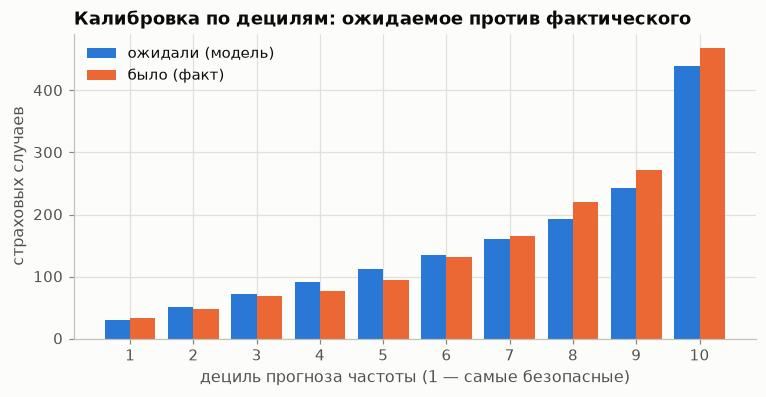

> ▸ **Вывод.** Отношения 0.8–1.2 в децилях с 30–470 случаями — в пределах случайного разброса (±√N): калибровка приемлема.

In [6]:
dec = np.digitize(p_exp, np.quantile(p_exp, np.linspace(0.1, 0.9, 9)))
print("   дециль  ожидали  было   отношение")
for d in range(10):
    k = dec == d
    print(f"   {d + 1:5d}   {p_exp[k].sum():7.1f} {claims[te][k].sum():6d}   {claims[te][k].sum() / p_exp[k].sum():.2f}")
print(f"   итого   {p_exp.sum():7.1f} {claims[te].sum():6d}")
top, bottom = claims[te][dec == 9].sum() / (dec == 9).sum(), claims[te][dec == 0].sum() / (dec == 0).sum()
print(f"   частота в верхнем дециле в {top / bottom:.1f} раза выше, чем в нижнем — модель разделяет риск")
fig, ax = plt.subplots(figsize=(8, 3.6))
d = np.arange(1, 11)
ax.bar(d - 0.2, [p_exp[dec == i].sum() for i in range(10)], width=0.4, color=ROLE["model"], label="ожидали (модель)")
ax.bar(d + 0.2, [claims[te][dec == i].sum() for i in range(10)], width=0.4, color=ROLE["tree"], label="было (факт)")
ax.set_xticks(d)
ax.set(xlabel="дециль прогноза частоты (1 — самые безопасные)", ylabel="страховых случаев",
       title="Калибровка по децилям: ожидаемое против фактического")
ax.legend()
ex.finish(fig, "25_deciles")
ex.note("Отношения 0.8–1.2 в децилях с 30–470 случаями — в пределах случайного разброса (±√N): калибровка приемлема.")

## Этап 6. Выводы

In [7]:
ex.note("""Счётная цель — Пуассон, «нули + хвост» — Твиди; обе с логарифмической связью и смещением на экспозицию.
Сравнивайте модели девиацией, а не MSE, и проверяйте, что суммы по группам сходятся с фактом.""")
ex.done()

> ▸ **Вывод.** Счётная цель — Пуассон, «нули + хвост» — Твиди; обе с логарифмической связью и смещением на экспозицию. Сравнивайте модели девиацией, а не MSE, и проверяйте, что суммы по группам сходятся с фактом.

Готово за 3.1 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Передайте экспозицию обычным признаком вместо смещения — что станет с годовой частотой?
2. Смоделируйте ущерб как частота (Пуассон) × средний ущерб (Гамма) и сравните с Твиди.
3. Постройте кривую Лоренца и коэффициент Джини для ранжирования полисов по риску.

## Что дальше

- **Теория в курсе:** [5.3 «Потери для регрессии»](../../../lessons/lesson_5_3/README.md), [10.3 «Свои потери»](../../../lessons/lesson_10_3/README.md).
- **Предыдущий пример:** [24. Ранжирование поисковой выдачи: 5000 запросов, ~150 000 пар «запрос — документ»](24_learning_to_rank.ipynb)
- **Следующий пример:** [26. Интервалы прогноза: квантильный бустинг и конформная калибровка (CQR)](26_prediction_intervals.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)